# Bias Analysis

This notebook investigates potential bias in loan approval outcomes across gender, age, and geographic indicators using the cleaned credit application data.


## Table of Contents

1. Approval Pattern
2. Gender Disparate Impact
3. Age Based Bias Patterns
4. Proxy Discrimination Through Geography
5. Interaction Effects: Age and Gender
6. Controlled Bias Check with Logistic Regression
7. Fairness Metric Using a Fairness Library


In [83]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2, chi2_contingency

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")


def cramers_v(contingency: pd.DataFrame) -> float:
    # Association strength for two categorical variables.
    chi2_stat = chi2_contingency(contingency)[0]
    n = contingency.to_numpy().sum()
    rows, cols = contingency.shape
    denom = n * min(rows - 1, cols - 1)
    return np.sqrt(chi2_stat / denom) if denom else np.nan


def wilson_interval(successes: int, total: int, alpha: float = 0.05) -> tuple[float, float]:
    # 95% CI for a binary approval rate.
    return sm.stats.proportion_confint(successes, total, alpha=alpha, method="wilson")


def bootstrap_di(df: pd.DataFrame, group_col: str, outcome_col: str, advantaged: str, disadvantaged: str, n_boot: int = 2000, seed: int = 42) -> tuple[float, float]:
    # Bootstrap CI for the disparate impact ratio.
    rng = np.random.default_rng(seed)
    di_values = []
    for _ in range(n_boot):
        sample = df.sample(len(df), replace=True, random_state=int(rng.integers(0, 1_000_000)))
        rates = sample.groupby(group_col)[outcome_col].mean()
        if advantaged in rates and disadvantaged in rates and rates[advantaged] > 0:
            di_values.append(rates[disadvantaged] / rates[advantaged])
    return tuple(np.quantile(di_values, [0.025, 0.975]))


In [84]:
candidate_paths = [
    Path("../data/clean_credit_applications.json"),
    Path("data/clean_credit_applications.json"),
]
data_path = next(path for path in candidate_paths if path.exists())
raw_df = pd.read_json(data_path)

df = raw_df.copy()
df["approved"] = df["decision.loan_approved"].astype(int)
df["gender"] = df["applicant_info.gender"].astype("object")
df["age"] = pd.to_numeric(df["demographics.age"], errors="coerce")
df["zip_code"] = df["applicant_info.zip_code"].astype(str)
df["zip_prefix"] = df["zip_code"].str[:3]

audit_df = df[df["gender"].isin(["female", "male"])].copy()
analysis_df = audit_df.dropna(subset=["age"]).copy()

print(f"Rows in cleaned dataset: {len(df)}")
print(f"Rows with binary gender labels for fairness audit: {len(audit_df)}")
print(f"Rows retained for age-sensitive analyses: {len(analysis_df)}")
print()
print("Missing values in core audit columns:")
print(df[["gender", "age", "approved", "zip_code"]].isna().sum())

analysis_df.head()


Rows in cleaned dataset: 500
Rows with binary gender labels for fairness audit: 498
Rows retained for age-sensitive analyses: 495

Missing values in core audit columns:
gender      2
age         4
approved    0
zip_code    0
dtype: int64


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,notes,date_parsed,parsed_dob,demographics.age,email_valid,approved,gender,age,zip_code,zip_prefix
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-03-09,10036,...,NaN,9.840960e+11,9.840960e+11,24.0,True,0,male,24.0,10036,100
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",None,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,1992-03-31,10032,...,NaN,7.020000e+11,7.020000e+11,33.0,True,0,male,33.0,10032,100
2,app_215,"[{'category': 'Rent', 'amount': 109}]",None,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,1989-10-24,10075,...,NaN,6.251904e+11,6.251904e+11,36.0,True,1,male,36.0,10075,100
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",None,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,male,1983-04-25,10077,...,NaN,4.200768e+11,4.200768e+11,42.0,True,1,male,42.0,10077,100
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,male,1999-05-21,10080,...,NaN,9.272448e+11,9.272448e+11,26.0,True,0,male,26.0,10080,100


## 1. Approval Pattern

This section establishes the overall approval rate as a baseline reference point for the bias analysis that follows


Overall approval rate: 0.582


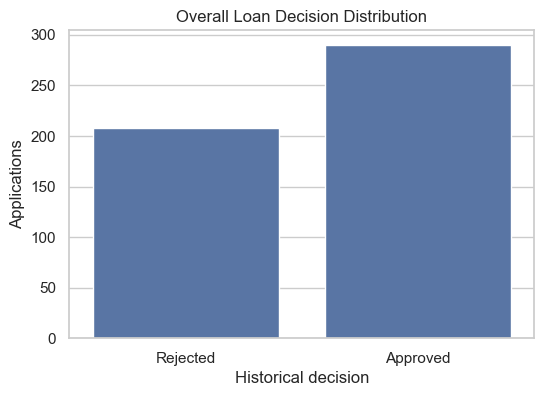

In [85]:
overall_rate = audit_df["approved"].mean()
print(f"Overall approval rate: {overall_rate:.3f}")

plt.figure(figsize=(6, 4))
sns.countplot(data=audit_df, x="approved")
plt.xticks([0, 1], ["Rejected", "Approved"])
plt.title("Overall Loan Decision Distribution")
plt.xlabel("Historical decision")
plt.ylabel("Applications")
plt.show()


**1.1 Interpretation** 

The dataset contains a total of approximately 500 loan applications, of which 58.2% were approved and the remaining 41.8% were rejected. The distribution, shown in the bar chart, confirms that approvals outnumber rejections. This establishes a moderately selective lending environment, which serves as the baseline.


## 2. Gender Disparate Impact

This section investigates potential gender based disparities in loan approval outcomes, applying the four fifths rule as the primary fairness benchmark alongside statistical testing to validate the findings.

        approvals  applications  approval_rate  \
gender                                           
female        127           251       0.505976   
male          163           247       0.659919   

                                           ci_95  
gender                                            
female  (0.4445023921207533, 0.5672696327839967)  
male    (0.5987935711309156, 0.7161463928264404)  

Female approval rate: 0.506
Male approval rate:   0.660
Disparate impact ratio (female/male): 0.767
95% bootstrap CI for DI: (0.659, 0.890)
Absolute approval gap: 0.154
Chi-square p-value: 0.000694
Interpretation: DI is below 0.80, so the four-fifths rule flags potential gender disparate impact.


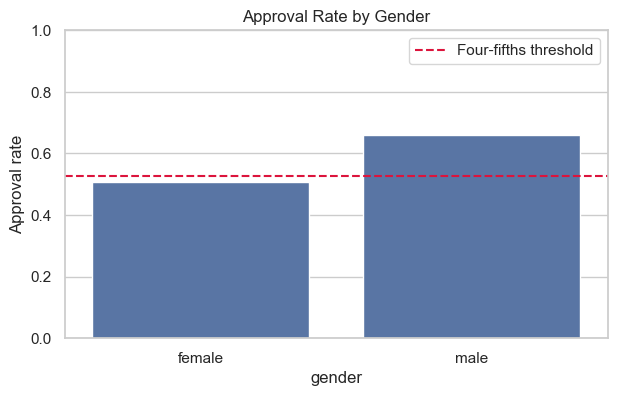

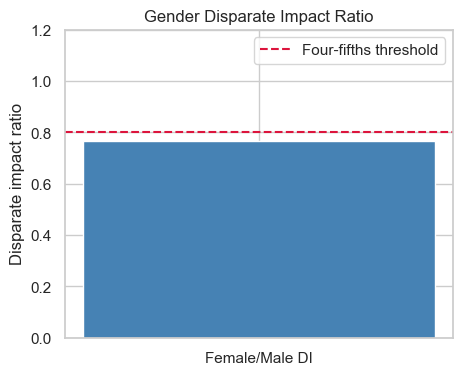

In [86]:
gender_summary = (
    audit_df.groupby("gender")
    .agg(
        approvals=("approved", "sum"),
        applications=("approved", "size"),
        approval_rate=("approved", "mean"),
    )
    .sort_index()
)

gender_summary["ci_95"] = gender_summary.apply(
    lambda row: wilson_interval(int(row["approvals"]), int(row["applications"])),
    axis=1,
)

female_rate = gender_summary.loc["female", "approval_rate"]
male_rate = gender_summary.loc["male", "approval_rate"]
di_gender = female_rate / male_rate
di_gender_ci = bootstrap_di(audit_df, "gender", "approved", advantaged="male", disadvantaged="female")
abs_gap_gender = male_rate - female_rate

gender_contingency = pd.crosstab(audit_df["gender"], audit_df["approved"])
chi2_stat, p_gender, dof_gender, expected_gender = chi2_contingency(gender_contingency)

print(gender_summary)
print()
print(f"Female approval rate: {female_rate:.3f}")
print(f"Male approval rate:   {male_rate:.3f}")
print(f"Disparate impact ratio (female/male): {di_gender:.3f}")
print(f"95% bootstrap CI for DI: ({di_gender_ci[0]:.3f}, {di_gender_ci[1]:.3f})")
print(f"Absolute approval gap: {abs_gap_gender:.3f}")
print(f"Chi-square p-value: {p_gender:.6f}")

if di_gender < 0.8:
    print("Interpretation: DI is below 0.80, so the four-fifths rule flags potential gender disparate impact.")
else:
    print("Interpretation: DI is at or above 0.80, so the four-fifths rule does not flag gender disparate impact.")

plt.figure(figsize=(7, 4))
sns.barplot(data=gender_summary.reset_index(), x="gender", y="approval_rate")
plt.axhline(0.8 * male_rate, color="crimson", linestyle="--", label="Four-fifths threshold")
plt.ylim(0, 1)
plt.title("Approval Rate by Gender")
plt.ylabel("Approval rate")
plt.legend()
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(["Female/Male DI"], [di_gender], color="steelblue")
plt.axhline(0.8, color="crimson", linestyle="--", label="Four-fifths threshold")
plt.ylim(0, 1.2)
plt.title("Gender Disparate Impact Ratio")
plt.ylabel("Disparate impact ratio")
plt.legend()
plt.show()


**2.1 Interpretation** 

The results show a clear gap in approval rates between male and female applicants. Females were approved at 50.6% compared to 66.0% for males, 15.4 percentage points difference. 

The disparate impact ratio is 0.767, which is below the four-fifths rule of 0.80, indicating that the rate at which female applicants are being approved is 77% compared to male applicants. Raising concerns of potential disparate impact. Bootstrap resampling was used to validate this result without making assumptions about the data distribution, producing a 95% CI of (0.659, 0.890). Since the entire interval falls below 1.0, the observed gap is not due to sampling variation. The chi-square test (p = 0.000694) further supports this, as the difference in approval rates between the two groups is statistically significant and very unlikely to have occurred by chance.

All three metrics point to the same conclusion: female applicants were at a clear disadvantage when it came to loan approval outcomes.

## 3. Age Based Bias Patterns

Applicants were grouped into five age brackets to examine whether approval rates shift across different stages of life and whether any observed gaps are large enough to indicate potential age-based bias

           approvals  applications  approval_rate
age_group                                        
18-24              6            13       0.461538
25-34             68           149       0.456376
35-44            116           177       0.655367
45-54             56            87       0.643678
55+               42            69       0.608696

Disparate impact ratio (25-34 vs 35-44): 0.696
Chi-square p-value for age-group vs approval: 0.003131
Pairwise proportion-test p-value (25-34 vs 35-44): 0.000307


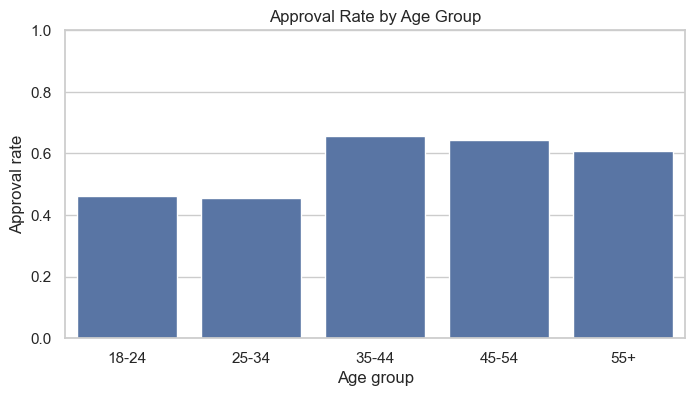

In [87]:
age_bins = [18, 25, 35, 45, 55, np.inf]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False,
)

age_summary = (
    analysis_df.groupby("age_group", observed=True)
    .agg(
        approvals=("approved", "sum"),
        applications=("approved", "size"),
        approval_rate=("approved", "mean"),
    )
)

youngest_rate = age_summary.loc["25-34", "approval_rate"]
reference_rate = age_summary.loc["35-44", "approval_rate"]
di_age = youngest_rate / reference_rate

young_group = analysis_df[analysis_df["age_group"] == "25-34"]
reference_group = analysis_df[analysis_df["age_group"] == "35-44"]
age_pair_stat, age_pair_p = proportions_ztest(
    count=[young_group["approved"].sum(), reference_group["approved"].sum()],
    nobs=[len(young_group), len(reference_group)],
)

age_contingency = pd.crosstab(analysis_df["age_group"], analysis_df["approved"])
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_contingency)

print(age_summary)
print()
print(f"Disparate impact ratio (25-34 vs 35-44): {di_age:.3f}")
print(f"Chi-square p-value for age-group vs approval: {p_age:.6f}")
print(f"Pairwise proportion-test p-value (25-34 vs 35-44): {age_pair_p:.6f}")

plt.figure(figsize=(8, 4))
sns.barplot(data=age_summary.reset_index(), x="age_group", y="approval_rate")
plt.ylim(0, 1)
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval rate")
plt.xlabel("Age group")
plt.show()


**3.1 Interpretation** 

Younger applicants were approved at much lower rates than older ones. The 25-34 group had an approval rate of 45.6%, while the 35-44 group was 65.5%, giving a disparate impact ratio of 0.696, which is below the 0.80 threshold and flags a potential age-based bias. The 18-24 group also had a low rate of 46.2%, though with only 13 applications in that group, therefore this result should be treated with causion. 

The chi square test (p = 0.003131) confirms that approval rates differ significantly across age groups. However, since the chi-square test looks at all groups at once, a pairwise proportion test was also run specifically on the 25-34 vs 35-44 comparison to isolate and confirm that gap on its own. The result (p = 0.000307) confirms the difference between these two groups is statistically significant. Concluding that younger applicants especially those in the  25-34 group, were at a clear disadvantage compared to the middle aged group.


## 4. Proxy Discrimination Through Geography

This section looks at whether geography acts as a proxy for gender in loan approval outcomes. Since individual ZIP codes appear too rarely in the data to draw reliable conclusions, ZIP prefix is used instead to capture geography more stably. The analysis tests how strongly ZIP prefix is associated with gender, whether approval rates differ across geographic groups, and how it compares to other potential proxy variables like income band and loan purpose.


ZIP-prefix by gender contingency table:
gender      female  male
zip_prefix              
100             28   221
300              8    10
902            213    15

Chi-square p-value: 1.352770e-70
Cramer's V: 0.806
Approval-rate spread across ZIP prefixes: 0.125

Proxy comparison across candidate variables:
    candidate_proxy  chi_square_p  cramers_v
0        zip_prefix  1.352770e-70   0.806235
2      loan_purpose  2.741117e-01   0.469539
1       income_band  2.215863e-01   0.107983
3  spend_total_band  3.264332e-01   0.096803

Geographic proxy summary:
  zip_prefix  approval_rate  female_share    n
0        100       0.642570      0.112450  249
1        300       0.555556      0.444444   18
2        902       0.517544      0.934211  228

Interpretation: ZIP prefix is strongly associated with gender and is therefore a plausible proxy attribute.
Income band was checked as a second proxy candidate, but it is much weaker than geography in this dataset.
Loan purpose was tested on observ

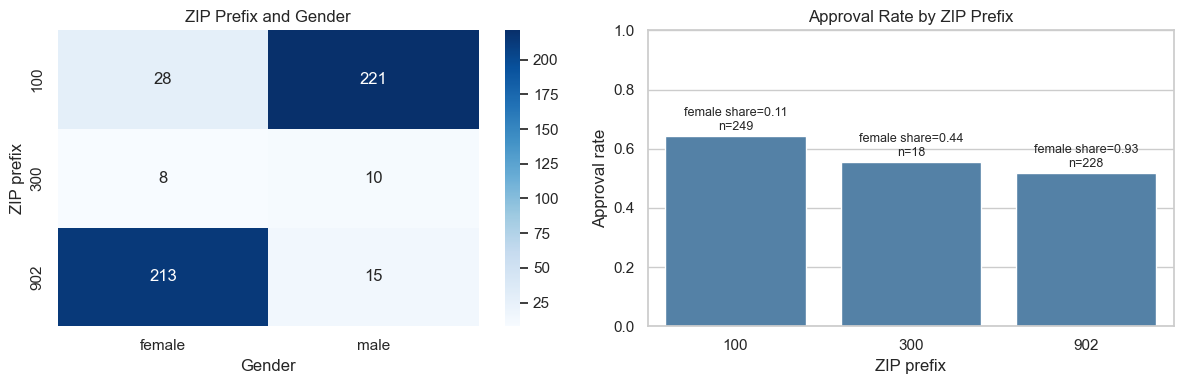

In [88]:
proxy_contingency = pd.crosstab(analysis_df["zip_prefix"], analysis_df["gender"])
chi2_proxy, p_proxy, dof_proxy, expected_proxy = chi2_contingency(proxy_contingency)
proxy_strength = cramers_v(proxy_contingency)

analysis_df["income_band"] = pd.qcut(analysis_df["financials.annual_income"], q=5, duplicates="drop")
income_proxy_contingency = pd.crosstab(analysis_df["income_band"], analysis_df["gender"])
chi2_income_proxy, p_income_proxy, _, _ = chi2_contingency(income_proxy_contingency)
income_proxy_strength = cramers_v(income_proxy_contingency)

loan_purpose_df = analysis_df.dropna(subset=["loan_purpose"]).copy()
loan_purpose_contingency = pd.crosstab(loan_purpose_df["loan_purpose"], loan_purpose_df["gender"])
chi2_loan_proxy, p_loan_proxy, _, _ = chi2_contingency(loan_purpose_contingency)
loan_proxy_strength = cramers_v(loan_purpose_contingency)

analysis_df["spend_total"] = analysis_df["spending_behavior"].apply(
    lambda items: sum(item.get("amount", 0) for item in (items or []))
)
analysis_df["spend_total_band"] = pd.qcut(analysis_df["spend_total"], q=5, duplicates="drop")
spending_proxy_contingency = pd.crosstab(analysis_df["spend_total_band"], analysis_df["gender"])
chi2_spending_proxy, p_spending_proxy, _, _ = chi2_contingency(spending_proxy_contingency)
spending_proxy_strength = cramers_v(spending_proxy_contingency)

proxy_summary = (
    analysis_df.groupby("zip_prefix")
    .agg(
        approval_rate=("approved", "mean"),
        female_share=("gender", lambda s: (s == "female").mean()),
        n=("approved", "size"),
    )
    .reset_index()
    .sort_values("female_share")
)

approval_spread = proxy_summary["approval_rate"].max() - proxy_summary["approval_rate"].min()

print("ZIP-prefix by gender contingency table:")
print(proxy_contingency)
print()
print(f"Chi-square p-value: {p_proxy:.6e}")
print(f"Cramer's V: {proxy_strength:.3f}")
print(f"Approval-rate spread across ZIP prefixes: {approval_spread:.3f}")
print()
print("Proxy comparison across candidate variables:")
proxy_candidate_summary = pd.DataFrame({
    "candidate_proxy": ["zip_prefix", "income_band", "loan_purpose", "spend_total_band"],
    "chi_square_p": [p_proxy, p_income_proxy, p_loan_proxy, p_spending_proxy],
    "cramers_v": [proxy_strength, income_proxy_strength, loan_proxy_strength, spending_proxy_strength],
}).sort_values("cramers_v", ascending=False)
print(proxy_candidate_summary)
print()
print("Geographic proxy summary:")
print(proxy_summary)
print()
if p_proxy < 0.05 and proxy_strength >= 0.3:
    print("Interpretation: ZIP prefix is strongly associated with gender and is therefore a plausible proxy attribute.")
else:
    print("Interpretation: ZIP prefix does not show enough association strength to be treated as a strong proxy attribute.")
if p_income_proxy < 0.05 and income_proxy_strength >= 0.3:
    print("Income band also looks like a strong proxy candidate in this dataset.")
else:
    print("Income band was checked as a second proxy candidate, but it is much weaker than geography in this dataset.")
if p_loan_proxy < 0.05 and loan_proxy_strength >= 0.3:
    print("Loan purpose also behaves like a strong proxy candidate.")
else:
    print("Loan purpose was tested on observed values only, and the evidence is weaker and less stable than geography.")
if p_spending_proxy < 0.05 and spending_proxy_strength >= 0.3:
    print("Total spending band also behaves like a strong behavioral proxy candidate.")
else:
    print("Engineered spending totals were tested, but they are weak proxy candidates in this dataset.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(proxy_contingency, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("ZIP Prefix and Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("ZIP prefix")

sns.barplot(data=proxy_summary, x="zip_prefix", y="approval_rate", ax=axes[1], color="steelblue")
for _, row in proxy_summary.iterrows():
    axes[1].text(row.name, row["approval_rate"] + 0.02, f"female share={row['female_share']:.2f}\nn={int(row['n'])}", ha="center", fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].set_title("Approval Rate by ZIP Prefix")
axes[1].set_xlabel("ZIP prefix")
axes[1].set_ylabel("Approval rate")

plt.tight_layout()
plt.show()


**4.1 Interpretation** 

The most notable finding in this section is how strongly ZIP prefix is linked to gender. The contingency table makes this very clear. ZIP prefix 100 is overwhelmingly male (221 vs 28 female applicants), while ZIP prefix 902 is almost entirely female (213 vs 15 male applicants). The chi-square test was used to determine whether this distribution between ZIP prefix and gender was statistically significant, and the result confirms it is not random. Cramer's V was then included to go a step further and measure the actual strength of that association, since chi-square alone only tells us whether a relationship exists, not how strong it is. At 0.806, the Cramer's V indicates a very strong association between geography and gender.

What makes this concerning is that approval rates follow the exact same pattern. Prefix 100, which is mostly male, has the highest approval rate at 64.3%, while prefix 902, which is mostly female, sits at the lowest at 51.8%. Given how closely geography and gender overlap in this dataset, using ZIP prefix as a feature would essentially capture gender information, even without intending to.
To check whether other variables could also act as proxies, income band, loan purpose, and total spending were tested as alternatives. None of them came close to geography, with Cramer's V values well below 0.5 and p-values above 0.05 across the board. The approval rate spread of 12.5 percentage points across ZIP prefixes further reinforces that geography is by far the strongest proxy candidate in this dataset.

## 5. Interaction Effects: Age and Gender

This section examines whether age and gender combined create disadvantages that go beyond their individual effects, using descriptive approval rates and a formal likelihood-ratio test.


  age_group  gender  approval_rate
0     18-24  female       0.500000
1     18-24    male       0.428571
2     25-34  female       0.341772
3     25-34    male       0.585714
4     35-44  female       0.588235
5     35-44    male       0.717391
6     45-54  female       0.625000
7     45-54    male       0.659574
8       55+  female       0.538462
9       55+    male       0.700000

Selected intersectional DI comparisons:
                   comparison  disparate_impact_ratio
0  Female 25-34 vs Male 25-34                0.583513
1  Female 25-34 vs Male 35-44                0.476410
2      Female 55+ vs Male 55+                0.769231

Likelihood-ratio test for the interaction model:
LR statistic: 3.099
Degrees of freedom: 4
P-value: 0.541403

Interaction coefficients:
C(gender)[T.male]:C(age_group)[T.25-34] 1.267 0.28387
C(gender)[T.male]:C(age_group)[T.35-44] 0.731 0.535007
C(gender)[T.male]:C(age_group)[T.45-54] 0.414 0.734984
C(gender)[T.male]:C(age_group)[T.55+] 0.933 0.454124


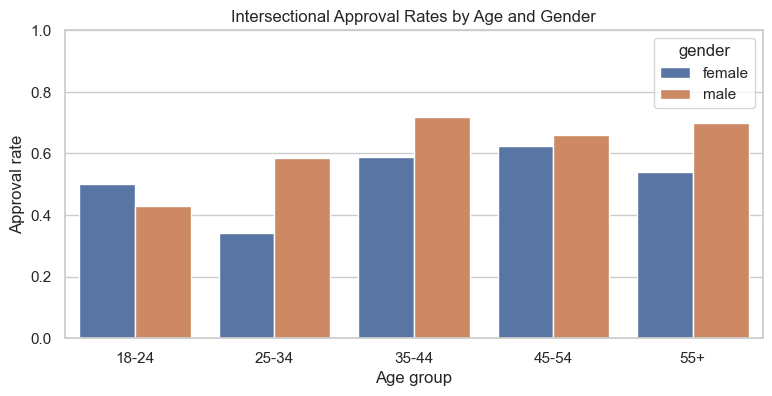

In [89]:
intersection_rates = (
    analysis_df.groupby(["age_group", "gender"], observed=True)["approved"]
    .mean()
    .rename("approval_rate")
    .reset_index()
)
print(intersection_rates)

intersection_lookup = intersection_rates.set_index(["age_group", "gender"])["approval_rate"]
intersection_comparisons = pd.DataFrame({
    "comparison": [
        "Female 25-34 vs Male 25-34",
        "Female 25-34 vs Male 35-44",
        "Female 55+ vs Male 55+",
    ],
    "disparate_impact_ratio": [
        intersection_lookup[("25-34", "female")] / intersection_lookup[("25-34", "male")],
        intersection_lookup[("25-34", "female")] / intersection_lookup[("35-44", "male")],
        intersection_lookup[("55+", "female")] / intersection_lookup[("55+", "male")],
    ],
})
print()
print("Selected intersectional DI comparisons:")
print(intersection_comparisons)

main_effects_model = smf.logit(
    "approved ~ C(gender) + C(age_group) + Q('financials.annual_income') + Q('financials.debt_to_income') + Q('financials.credit_history_months') + Q('financials.savings_balance')",
    data=analysis_df,
).fit(disp=0)

interaction_model = smf.logit(
    "approved ~ C(gender) * C(age_group) + Q('financials.annual_income') + Q('financials.debt_to_income') + Q('financials.credit_history_months') + Q('financials.savings_balance')",
    data=analysis_df,
).fit(disp=0)

lr_stat = 2 * (interaction_model.llf - main_effects_model.llf)
lr_df = interaction_model.df_model - main_effects_model.df_model
lr_p_value = chi2.sf(lr_stat, lr_df)

print()
print("Likelihood-ratio test for the interaction model:")
print(f"LR statistic: {lr_stat:.3f}")
print(f"Degrees of freedom: {lr_df:.0f}")
print(f"P-value: {lr_p_value:.6f}")
print()
print("Interaction coefficients:")
for term in interaction_model.params.index:
    if ":" in term:
        print(term, round(interaction_model.params[term], 3), round(interaction_model.pvalues[term], 6))

plt.figure(figsize=(9, 4))
sns.barplot(data=intersection_rates, x="age_group", y="approval_rate", hue="gender")
plt.ylim(0, 1)
plt.title("Intersectional Approval Rates by Age and Gender")
plt.ylabel("Approval rate")
plt.xlabel("Age group")
plt.show()


**5.1 Interpretation** 

Examining age and gender together reveals that some subgroups are considerably worse off than the individual effects would suggest. Female applicants in the 25-34 group had an approval rate of just 34.2%, compared to 58.6% for males in the same age group. The resulting DI ratio of 0.584 is well below the four fifths rule, 0.80 threshold.When compared against male applicants in the 35-44 group, that ratio drops further to 0.476, meaning young female applicants were approved at less than half the rate of middle-aged male applicants. The gap narrows slightly in the 55+ group, with a DI ratio of 0.769, though it still falls below the 0.80 threshold.

A p-value of 0.541 on the likelihood-ratio test indicates no meaningful interaction between age and gender. The descriptive gaps are real, but age and gender appear to be acting independently rather than reinforcing one another.

Young female applicants clearly face the largest gaps in approval outcomes, though the formal test suggests this reflects two separate disadvantages stacking rather than a single compounded effect.

## 6. Controlled Bias Check with Logistic Regression

The previous sections highlighted clear descriptive gaps, but it is worth testing whether those gaps hold up once financial risk factors are taken into account. Two logistic regression models were run to assess this, with the second adding ZIP prefix to see whether including a proxy variable affects the gender effec


Controlled model: key coefficients
                                       coefficient  odds_ratio   p_value
C(gender)[T.male]                         0.697058    2.007838  0.000284
age                                      -0.005941    0.994076  0.623776
Q('financials.debt_to_income')            0.527903    1.695373  0.452494
Q('financials.credit_history_months')     0.008688    1.008726  0.032462

Controlled model with geography proxy added: key coefficients
                                       coefficient  odds_ratio   p_value
C(gender)[T.male]                         0.642647    1.901508  0.046190
age                                      -0.005891    0.994127  0.626989
Q('financials.debt_to_income')            0.518716    1.679870  0.460556
Q('financials.credit_history_months')     0.008714    1.008752  0.032130

Male odds ratio without proxy: 2.008
Male gender p-value without proxy: 0.000284
Male odds ratio with zip proxy: 1.902
Male gender p-value with zip proxy: 0.046190


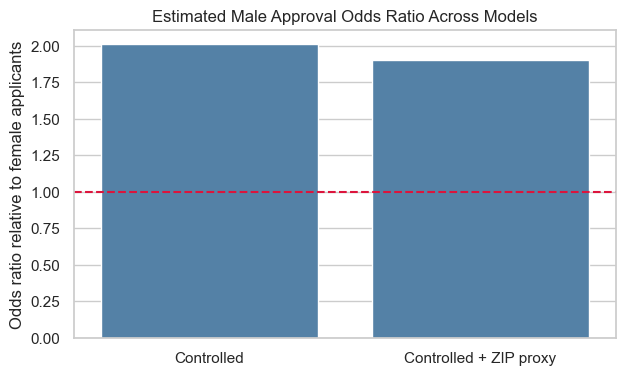

In [90]:
df_reg = analysis_df.dropna(subset=[
    "approved",
    "financials.annual_income",
    "financials.debt_to_income",
    "financials.credit_history_months",
    "financials.savings_balance",
    "age",
    "gender",
    "zip_prefix",
]).copy()

controlled_model = smf.logit(
    "approved ~ Q('financials.annual_income') + Q('financials.debt_to_income') + Q('financials.credit_history_months') + Q('financials.savings_balance') + age + C(gender)",
    data=df_reg,
).fit(disp=0)

proxy_controlled_model = smf.logit(
    "approved ~ Q('financials.annual_income') + Q('financials.debt_to_income') + Q('financials.credit_history_months') + Q('financials.savings_balance') + age + C(gender) + C(zip_prefix)",
    data=df_reg,
).fit(disp=0)

gender_term = "C(gender)[T.male]"

controlled_results = pd.DataFrame({
    "coefficient": controlled_model.params,
    "odds_ratio": np.exp(controlled_model.params),
    "p_value": controlled_model.pvalues,
})

proxy_controlled_results = pd.DataFrame({
    "coefficient": proxy_controlled_model.params,
    "odds_ratio": np.exp(proxy_controlled_model.params),
    "p_value": proxy_controlled_model.pvalues,
})

print("Controlled model: key coefficients")
print(controlled_results.loc[[
    gender_term,
    "age",
    "Q('financials.debt_to_income')",
    "Q('financials.credit_history_months')",
]])
print()
print("Controlled model with geography proxy added: key coefficients")
print(proxy_controlled_results.loc[[
    gender_term,
    "age",
    "Q('financials.debt_to_income')",
    "Q('financials.credit_history_months')",
]])
print()
print(f"Male odds ratio without proxy: {controlled_results.loc[gender_term, 'odds_ratio']:.3f}")
print(f"Male gender p-value without proxy: {controlled_results.loc[gender_term, 'p_value']:.6f}")
print(f"Male odds ratio with zip proxy: {proxy_controlled_results.loc[gender_term, 'odds_ratio']:.3f}")
print(f"Male gender p-value with zip proxy: {proxy_controlled_results.loc[gender_term, 'p_value']:.6f}")

plt.figure(figsize=(7, 4))
gender_or_plot = pd.DataFrame({
    "model": ["Controlled", "Controlled + ZIP proxy"],
    "odds_ratio": [
        controlled_results.loc[gender_term, "odds_ratio"],
        proxy_controlled_results.loc[gender_term, "odds_ratio"],
    ],
})
sns.barplot(data=gender_or_plot, x="model", y="odds_ratio", color="steelblue")
plt.axhline(1.0, color="crimson", linestyle="--")
plt.title("Estimated Male Approval Odds Ratio Across Models")
plt.ylabel("Odds ratio relative to female applicants")
plt.xlabel("")
plt.show()


**6.1 Interpretation** 

Two logistic regression models were run to test whether the gender gap holds up after accounting for financial risk factors. In the first model, controlling for income, debt-to-income ratio, credit history, savings, and age, male applicants had an odds ratio of 2.008 (p = 0.000284). This means that after controlling for these financial factors, males were still twice as likely to be approved as female applicants, and the result is statistically significant.

When ZIP prefix was added to the second model as a proxy variable, the male odds ratio dropped slightly to 1.902 (p = 0.046), but remained significant. The gender effect remains largely unchanged when ZIP prefix is included, indicating that geography alone does not account for the disparity between male and female approval rates.

Credit history was the only other variable that came out as statistically significant in both models (p ≈ 0.032), while age and debt-to-income ratio did not reach significance. Even when financial risk factors are taken into account, the gender gap remains, which means it is not simply a result of male and female applicants having different financial backgrounds.


## 7. Fairness Metric Using a Fairness Library

To cross-validate the findings from earlier sections, the fairlearn library is used here to compute group selection rates across gender. As this analysis focuses on observed historical decisions rather than model predictions, the approved column serves directly as the outcome. A manual calculation runs alongside it to ensure reproducibility.


In [91]:
selection_rates = audit_df.groupby("gender")["approved"].mean()
demographic_parity_difference = selection_rates.max() - selection_rates.min()

print("Manual selection rates:")
print(selection_rates)
print()
print(f"Manual demographic parity difference: {demographic_parity_difference:.3f}")

try:
    from fairlearn.metrics import MetricFrame, selection_rate

    mf = MetricFrame(
        metrics=selection_rate,
        y_true=audit_df["approved"].to_numpy(),
        y_pred=audit_df["approved"].to_numpy(),
        sensitive_features=audit_df["gender"].to_numpy(),
    )

    print()
    print("Fairlearn selection rate by group:")
    print(mf.by_group)
    print(f"Fairlearn demographic parity difference: {mf.difference():.3f}")
except ImportError:
    print()
    print("fairlearn is not installed in this environment, so the manual fairness metric above is the reproducible result.")


Manual selection rates:
gender
female    0.505976
male      0.659919
Name: approved, dtype: float64

Manual demographic parity difference: 0.154

Fairlearn selection rate by group:
sensitive_feature_0
female    0.505976
male      0.659919
Name: selection_rate, dtype: float64
Fairlearn demographic parity difference: 0.154


**7.1 Interpretation** 

Both the manual calculation and the fairlearn output produced identical results, with female applicants having a selection rate of 50.6% compared to 66.0% for male applicants, with an approval gap of 0.154. The fact that both approaches agree adds further confidence to the finding and confirms it is not a result of how the metric was computed.

An approval gap of 0.154 represents a 15.4 percentage point difference in approval rates between male and female applicants, which is consistent with what was found in section 2 and reinforces that the gender disparity is a consistent pattern across different measurement approaches.